In [1]:
%pip install catboost scikit-learn rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 26.7 MB/s eta 0:00:00


In [2]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
raw = pd.read_csv("sample_data/physical_chemical_properties_of_organic_substances.csv")
raw.head()

,name,formula,CAS,smiles,InChI,InChIKey,molecular_weight,melting_point_K,boiling_point_K,heat_of_fusion,...,is_anhydride,is_acyl_halide,is_carbonate,is_carboxylate,is_hydroperoxide,is_peroxide,is_orthoester,is_methylenedioxy,is_orthocarbonate_ester,is_carboxylic_anhydride
0,ammonia,H3N,7664-41-7,N,InChI=1S/H3N/h1H3,QGZKDVFQNNGYKY-UHFFFAOYSA-N,17.030520,195.45,239.834319,332344.520308,...,False,False,False,False,False,False,False,False,False,False
1,"1,4-benzodioxane-2-carboxylic acid",C9H8O4,3663-80-7,O=C(O)C1COc2ccccc2O1,InChI=1S/C9H8O4/c10-9(11)8-5-12-6-3-1-2-4-7(6)...,HMBHAQMOBKLWRX-UHFFFAOYSA-N,180.157420,389.65,647.600000,193464.138196,...,False,False,False,False,False,False,False,False,False,False
2,acetylene,C2H2,74-86-2,C#C,InChI=1S/C2H2/c1-2/h1-2H,HSFWRNGVRCDJHI-UHFFFAOYSA-N,26.037280,192.40,189.000350,144561.951172,...,False,False,False,False,False,False,False,False,False,False
3,adenosine triphosphate,C10H16N5O13P3,56-65-5,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,InChI=1S/C10H16N5O13P3/c11-8-5-9(13-2-12-8)15(...,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,507.181023,449.15,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
4,rhodizonic acid,C6H2O6,118-76-3,O=c1c(O)c(O)c(=O)c(=O)c1=O,InChI=1S/C6H2O6/c7-1-2(8)4(10)6(12)5(11)3(1)9/...,WCJLIWFWHPOTAC-UHFFFAOYSA-N,170.076480,521.15,792.780000,75777.673668,...,False,False,False,False,False,False,False,False,False,False


In [4]:
properties = raw[['name', 'smiles']].copy()
properties = properties[properties['smiles'].notna()]
properties['MolWt'] = properties['smiles'].apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)))
properties['HeavyAtomCount'] = properties['smiles'].apply(lambda x: Descriptors.HeavyAtomCount(Chem.MolFromSmiles(x)))
properties['MolLogP'] = properties['smiles'].apply(lambda x: Descriptors.MolLogP(Chem.MolFromSmiles(x)))
properties['TPSA'] = properties['smiles'].apply(lambda x: Descriptors.TPSA(Chem.MolFromSmiles(x)))
properties['NumHDonors'] = properties['smiles'].apply(lambda x: Descriptors.NumHDonors(Chem.MolFromSmiles(x)))
properties['NumHAcceptors'] = properties['smiles'].apply(lambda x: Descriptors.NumHAcceptors(Chem.MolFromSmiles(x)))
properties['NumAromaticRings'] = properties['smiles'].apply(lambda x: Descriptors.NumAromaticRings(Chem.MolFromSmiles(x)))
properties['NumRotatableBonds'] = properties['smiles'].apply(lambda x: Descriptors.NumRotatableBonds(Chem.MolFromSmiles(x)))
properties['NumHeteroatoms'] = properties['smiles'].apply(lambda x: Descriptors.NumHeteroatoms(Chem.MolFromSmiles(x)))
properties['melting_point_K'] = raw['melting_point_K']
properties['boiling_point_K'] = raw['boiling_point_K']
properties['heat_of_fusion'] = raw['heat_of_fusion']
properties['heat_of_vaporization'] = raw['heat_of_vaporization']
properties['critical_temperature'] = raw['critical_temperature']
properties['critical_pressure'] = raw['critical_pressure']
properties['flash_point'] = raw['flash_point']
properties.head()

[00:10:23] WARNING: not removing hydrogen atom without neighbors
[00:10:24] Unusual charge on atom 6 number of radical electrons set to zero
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WARNING: not removing hydrogen atom without neighbors
[00:10:24] WAR

,name,smiles,MolWt,HeavyAtomCount,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumAromaticRings,NumRotatableBonds,NumHeteroatoms,melting_point_K,boiling_point_K,heat_of_fusion,heat_of_vaporization,critical_temperature,critical_pressure,flash_point
0,ammonia,N,17.031,1,0.1620,35.00,1,1,0,0,1,195.45,239.834319,332344.520308,1.369669e+06,405.56000,11363400.0,NaN
1,"1,4-benzodioxane-2-carboxylic acid",O=C(O)C1COc2ccccc2O1,180.159,13,0.9110,55.76,1,3,1,1,4,389.65,647.600000,193464.138196,NaN,891.16869,4216562.7,NaN
2,acetylene,C#C,26.038,2,0.2494,0.00,0,0,0,0,0,192.40,189.000350,144561.951172,6.349685e+05,308.30000,5988200.0,NaN
3,adenosine triphosphate,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,507.182,31,-1.6290,279.13,7,14,2,8,21,449.15,NaN,NaN,NaN,NaN,NaN,NaN
4,rhodizonic acid,O=c1c(O)c(O)c(=O)c(=O)c1=O,170.076,12,-2.5858,108.74,2,6,1,0,6,521.15,792.780000,75777.673668,NaN,1083.97020,8541722.9,NaN


0:	learn: 62.3787418	test: 57.8866210	best: 57.8866210 (0)	total: 2.86ms	remaining: 28.6s
2000:	learn: 0.2088973	test: 32.1998308	best: 31.1126588 (92)	total: 2.21s	remaining: 8.85s
4000:	learn: 0.0065890	test: 32.2191822	best: 31.1126588 (92)	total: 2.77s	remaining: 4.15s
6000:	learn: 0.0002387	test: 32.2195868	best: 31.1126588 (92)	total: 3.33s	remaining: 2.22s
8000:	learn: 0.0000107	test: 32.2196136	best: 31.1126588 (92)	total: 3.93s	remaining: 981ms
9999:	learn: 0.0000005	test: 32.2196141	best: 31.1126588 (92)	total: 4.51s	remaining: 0us

bestTest = 31.11265876
bestIteration = 92

Shrink model to first 93 iterations.
Testing performance
RMSE: 31.11
R2: 0.74


Text(0.5, 1.0, 'Actual vs Predicted')

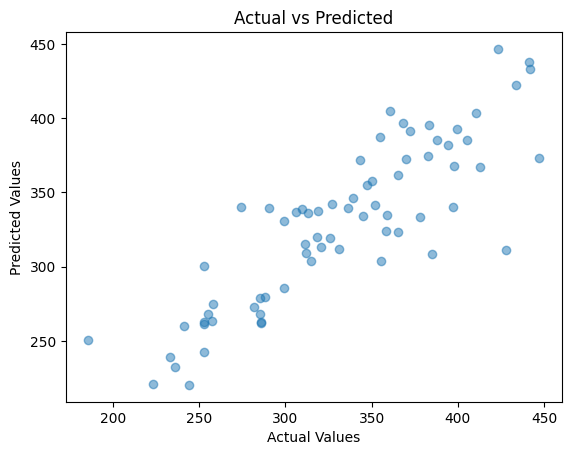

In [6]:
properties = properties[properties['flash_point'].notna()]
X = properties.drop(columns=['name', 'smiles', 'melting_point_K', 'boiling_point_K', 'heat_of_fusion', 'heat_of_vaporization', 'critical_temperature', 'critical_pressure', 'flash_point'])
y = properties['flash_point']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = CatBoostRegressor(iterations=10000, learning_rate=0.1, depth=4, verbose=2000, loss_function='RMSE')
model.fit(X_train, y_train, eval_set=(X_test, y_test))
predictions = model.predict(X_test)

rmse = (np.sqrt(mean_squared_error(y_test, predictions)))
r2 = r2_score(y_test, predictions)
print("Testing performance")
print('RMSE: {:.2f}'.format(rmse))
print('R2: {:.2f}'.format(r2))

plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
